## Aplicação de Métodos Estatísticos

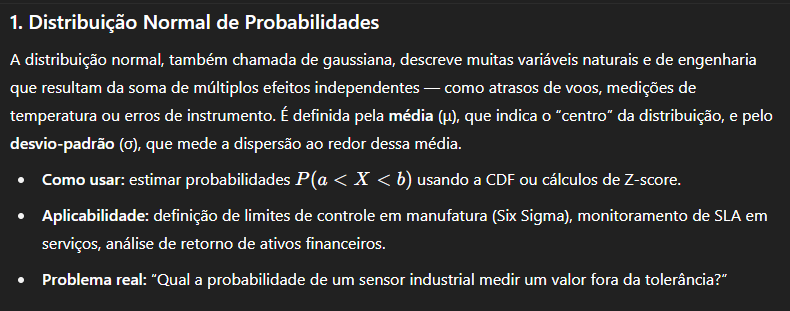

## Exercícios

In [47]:
import pandas as pd

# Dataset manual: atrasos de 10 voos (em minutos)
data_normal = {
    'flight_id': list(range(1, 11)),
    'delay':      [12, 5,  20, 15, 18, 3,  25, 10, 8,  17]
}
df_normal = pd.DataFrame(data_normal)
df_normal.head()

,flight_id,delay
0,1,12
1,2,5
2,3,20
3,4,15
4,5,18


### Exercício 1

1. Distribuição Normal de Probabilidades

Contexto: A companhia aérea VoeFácil monitora o atraso (delay) de seus 10 voos diários partindo de Congonhas. Os engenheiros acreditam que esses atrasos seguem uma distribuição normal.

Média e desvio-padrão

“Em um dia típico, com os 10 voos registrados em df_normal, qual a massa (média) e a variabilidade (desvio-padrão) dos atrasos?”

A) (13,3 min; 6,9 min)

B) (13,3 min; 6,4 min)

C) (14,0 min; 7,0 min)

D) (12,5 min; 6,0 min)

### Resposta

In [9]:
media_atrasos = df_normal["delay"].mean()
desvio_atrasos = df_normal["delay"].std()

print(f'Média de atrasos {media_atrasos}')
print(f'Desvio Padrão de atrasos {desvio_atrasos}\n')

print("RESPOSTA: A")

Média de atrasos 13.3
Desvio Padrão de atrasos 6.9610024820822725

RESPOSTA: A


### Exercício 2

2. Probabilidade de grande atraso

“Aproximadamente qual a chance de um voo atrasar mais de 18 min?”

A) ≈ 16%

B) ≈ 27%

C) ≈ 8%

D) ≈ 32%

### Resposta

In [4]:
# Importação da função norm
from scipy.stats import norm

In [5]:
percentual_atrasos_maior_18 = norm.sf(18, media_atrasos, desvio_atrasos) * 100
print(f'Probabilidade de {round(percentual_atrasos_maior_18,2)} % de atrasar mais que 18 min\n')

print("RESPOSTA: B")

Probabilidade de 24.98 % de atrasar mais que 18 min

RESPOSTA: B


### Exercício 3

3. Probabilidade de atraso moderado

“Em que probabilidade o atraso estará entre 8 e 20 min?”

A) ≈ 75%

B) ≈ 50%

C) ≈ 68%

D) ≈ 90%

### Resposta

In [6]:
# Calcula-se a probabilidade de 8 e 20 e depois subtrai para localizar a probabilidade do intervalo.

probabilidade_menor_8 = norm.cdf(8, media_atrasos, desvio_atrasos)
probabilidade_menor_20 = norm.cdf(20, media_atrasos, desvio_atrasos)
probabilidade_entre_8_e_20 = probabilidade_menor_20 - probabilidade_menor_8

#print(probabilidade_menor_8)
#print(probabilidade_menor_20)
#print(probabilidade_entre_8_e_20)

probabilidade_entre_8_e_20 = (probabilidade_entre_8_e_20 * 100)

print(f'A probabilidade de atraso entre 8 e 20 minutos é de {round(probabilidade_entre_8_e_20,2)} %')
print('RESPOSTA C')

A probabilidade de atraso entre 8 e 20 minutos é de 60.89 %
RESPOSTA C


### Exercício 4

4. Quantil de 75%

“Qual valor de atraso deixa 75% dos voos dentro desse limite?”

A) ≈ 17,5 min

B) ≈ 15,5 min

C) ≈ 19,0 min

D) ≈ 13,0 min

### Resposta

In [7]:
quantil_075 = df_normal["delay"].quantile(0.75)
print(f'O valor que corresponde a posição de 75% na distribuição é {quantil_075}')
print('RESPOSTA A')

O valor que corresponde a posição de 75% na distribuição é 17.75
RESPOSTA A


### Exercício 5

5. Intervalo de controle

“Se o SLA da companhia é μ ± 2σ, qual seria esse intervalo de atraso aceitável?”

A) (μ−2σ ; μ+2σ) preenchidos com seus valores

B) (μ−σ ; μ+σ)

C) (μ−3σ ; μ+3σ)

D) (μ−1,5σ ; μ+1,5σ)

### Resposta

In [8]:
desvio_atrasos = df_normal["delay"].std()
#print(desvio_atrasos)

media_atrasos = df_normal["delay"].mean()
#print(media_atrasos)

dois_desvios = desvio_atrasos * 2

maior_2_desvios = media_atrasos + dois_desvios
menor_2_desvios = media_atrasos - dois_desvios

print(f'RESPOSTA A: (μ−2σ ; μ+2σ) {menor_2_desvios:.2f}, {maior_2_desvios:.2f}')

RESPOSTA A: (μ−2σ ; μ+2σ) -0.62, 27.22


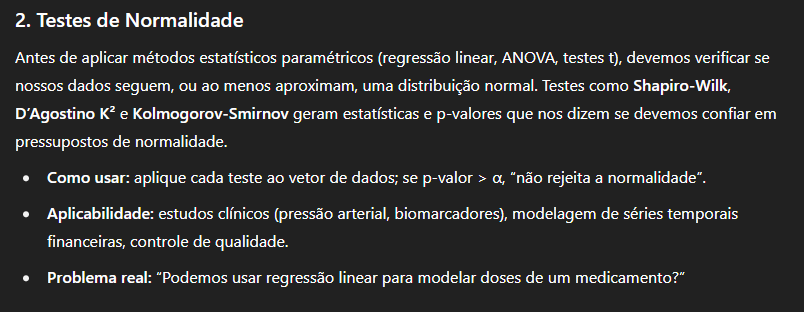

In [31]:
# Dataset manual: leituras de pressão arterial de 12 pacientes
data_normality = {
    'patient': list(range(1,13)),
    'bp':      [118, 125, 122, 119, 130, 117, 124, 121, 129, 120, 123, 127]
}
df_normality = pd.DataFrame(data_normality)
df_normality.head()

,patient,bp
0,1,118
1,2,125
2,3,122
3,4,119
4,5,130


## Exercícios

Testes de Normalidade

Contexto: No Hospital Santa Maria (interior de SP), mediram a pressão arterial (bp) de 12 pacientes para verificar se esses valores seguem normalidade antes de aplicar métodos estatísticos.

1. Shapiro-Wilk

“Realize o teste Shapiro-Wilk em df_normality.bp. Qual o p-valor e conclusão (α=0,05)?”

A) p≈0,90 → normal

B) p≈0,02 → não normal

C) p≈0,50 → normal

D) p≈0,005 → não normal

## Resposta

In [13]:
from scipy.stats import shapiro

In [37]:
stat, p_value = shapiro(df_normality['bp'])
print(f"Shapiro–Wilk stat={stat:.4f}, p={p_value:.4f}")

Shapiro–Wilk stat=0.9606, p=0.7919


In [16]:
print(f'Não rejeitamos a hipótese nula p-value p={p_value:.4f}, significa que os dados estam normalizados')
print('RESPOSTA A')

Não rejeitamos a hipótese nula p-value p=0.7919, significa que os dados estam normalizados
RESPOSTA A


## Exercícios

2. D’Agostino K²

“No mesmo conjunto, qual p-valor do teste D’Agostino e a conclusão?”

A) p>0,05 → normal

B) p<0,01 → não normal

C) estatística>0,2 → não normal

D) estatística<0,1 → normal

## Resposta

In [38]:
# O teste D’Agostino–Pearson (K²) avalia se os dados diferem de uma normal em termos de assimetria (skew) e curtose

from scipy.stats import normaltest
stat, p_value = normaltest(df_normality['bp'])

print(f"D’Agostino–Pearson (K²) stat={stat:.4f}, p={p_value:.4f}")
print('RESPOSTA A')

D’Agostino–Pearson (K²) stat=0.9084, p=0.6350
RESPOSTA A


C:\Users\Lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Exercício

3. Kolmogorov-Smirnov

“Compare bp com Normal(μ,σ) amostral. Qual é o resultado e interpretação?”

A) p>0,05 → normal

B) p<0,05 → não normal

C) D>0,2 → não normal

D) D<0,1 → normal

## Resposta

In [43]:
# O teste de Kolmogorov–Smirnov (KS) compara a distribuição empírica dos seus dados com uma distribuição teórica — no caso, a normal padrão N(0,1).
# Padronize os dados (z-score), pois o KS exige comparação com a distribuição padrão

from scipy.stats import kstest

bp = df_normality['bp']
bp_media = df_normality['bp'].mean()
bp_desvio = df_normality['bp'].std()

bp_z = (bp - bp_media) / bp_desvio
stat, p_value = kstest(bp_z, 'norm')

print(f"Kolmogorov-Smirnov stat={stat:.4f}, p={p_value:.4f}")
print('RESPOSTA A')

Kolmogorov-Smirnov stat=0.0914, p=0.9997
RESPOSTA A


## Exercício

4. Gráfico Q-Q

“Trace o Q-Q plot de bp e diga o que observa.”

A) Tendência linear → normal

B) Desvio nas caudas → não normal

C) Pontos dispersos → não normal

D) Todas as anteriores

## Resposta

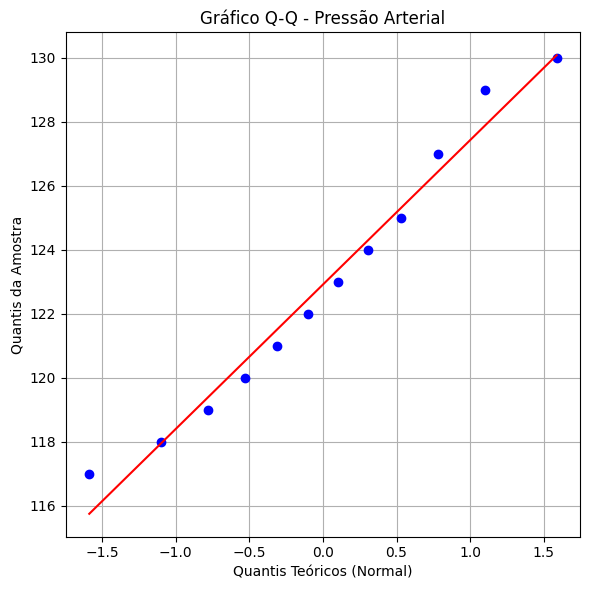

In [41]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6, 6))  # Tamanho do gráfico
stats.probplot(df_normality['bp'], dist="norm", plot=plt)  # Teste contra distribuição normal
plt.title("Gráfico Q-Q - Pressão Arterial")
plt.xlabel("Quantis Teóricos (Normal)")
plt.ylabel("Quantis da Amostra")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
print('RESPOSTA A')

RESPOSTA A


## Exercício

5. Decisão geral

“Com base em todos os testes, como você classifica bp?”

A) Distribuição normal

B) Não normal

C) Indeterminado

D) Precisa transformação

## Resposta

In [42]:
print('RESPOSTA A')

RESPOSTA A


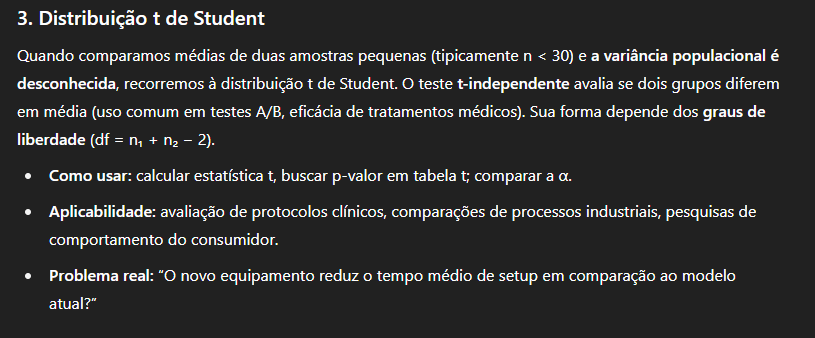

In [50]:
# Dataset manual: dias de recuperação
data_t = {
  'group':        ['treatment']*6 + ['control']*6,
  'recovery_days':[ 6,   8,   7,   9,    5,     7,    10,  11,  9,   12,   8,     10]
}
df_tstudent = pd.DataFrame(data_t)
df_tstudent.head()

,group,recovery_days
0,treatment,6
1,treatment,8
2,treatment,7
3,treatment,9
4,treatment,5


## Exercício

Distribuição T de Student

Contexto: Dois protocolos de recuperação são testados em pacientes de um mesmo hospital. Em df_tstudent, recovery_days mostra dias de alta para grupos “treatment” (novo protocolo) e “control” (padrão).

1. Teste t independente
   
“Há diferença significativa nas médias de dias de recuperação (α=0,05)?”

A) p≈0,03 → rejeita H₀

B) p≈0,10 → não rejeita H₀

C) p≈0,50 → não rejeita H₀

D) p≈0,001 → rejeita H₀

## Resposta

In [46]:
from scipy.stats import ttest_ind

treatment = df_tstudent[df_tstudent['group'] == 'treatment']['recovery_days']
control = df_tstudent[df_tstudent['group'] == 'control']['recovery_days']

# Aplicando o teste t 
stat, p_value = ttest_ind(treatment, control, equal_var=False)

# Exibindo os resultados
print(f"Estatística t = {stat:.4f}")
print(f"Valor-p = {p_value:.4f}")

# Interpretação
alpha = 0.05
if p_value < alpha:
    print("Resultado: Rejeitamos H₀ → há diferença significativa nas médias.")
else:
    print("Resultado: Não rejeitamos H₀ → não há diferença significativa.")

print('RESPOSTA D')

Estatística t = -3.6742
Valor-p = 0.0043
Resultado: Rejeitamos H₀ → há diferença significativa nas médias.
RESPOSTA D


## Exercícios

2. Média treatment

“Qual a média de dias de recuperação no protocolo novo?”

A) 7,0 dias

B) 8,0 dias

C) 6,5 dias

D) 9,0 dias

## Resposta

In [61]:
media = df_tstudent["recovery_days"].loc[df_tstudent["group"] == "treatment"].mean()
print(f'Média de dias para recuperação grupo novo protocólo: {media}')
print('RESPOSTA A') 

Média de dias para recuperação grupo novo protocólo: 7.0
RESPOSTA A


## Exercícios

3. Média control

“Qual a média de dias de recuperação no protocolo padrão?”

A) 9,0 dias

B) 10,0 dias

C) 7 dias

D) 11,0 dias

## Resposta

In [63]:
media = df_tstudent["recovery_days"].loc[df_tstudent["group"] == "control"].mean()
print(f'Média de dias para recuperação grupo protocólo padrão: {media}')
print('RESPOSTA B') 

Média de dias para recuperação grupo novo protocólo: 10.0
RESPOSTA B


## Exercícios

4. IC 95% da diferença

“Construa o intervalo de confiança para a diferença de médias.”

A) (–4; –1)

B) (–2; 2)

C) (0; 3)

D) (–1; 1)

## Resposta

In [59]:
import pandas as pd
import numpy as np
from scipy.stats import t

# 1. Criando os dados dos pacientes
data_t = {
    'group': ['treatment'] * 6 + ['control'] * 6,
    'recovery_days': [6, 8, 7, 9, 5, 7, 10, 11, 9, 12, 8, 10]
}
df = pd.DataFrame(data_t)

# 2. Separando os dois grupos
treatment = df[df['group'] == 'treatment']['recovery_days']
control = df[df['group'] == 'control']['recovery_days']

# 3. Calculando médias e desvios padrão
mean_diff = treatment.mean() - control.mean()
s1, s2 = treatment.std(ddof=1), control.std(ddof=1)
n1, n2 = len(treatment), len(control)

# 4. Calculando o erro padrão combinado
se = np.sqrt((s1**2 / n1) + (s2**2 / n2))

# 5. Calculando os graus de liberdade com a correção de Welch
df_welch = (s1**2 / n1 + s2**2 / n2)**2 / ((s1**2 / n1)**2 / (n1 - 1) + (s2**2 / n2)**2 / (n2 - 1))

# 6. Encontrando o t crítico para 95% de confiança (alpha = 0.05 → 2,5% em cada cauda)
t_crit = t.ppf(0.975, df_welch)

# 7. Calculando o intervalo de confiança
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se

# 8. Resultado final
print(f"Intervalo de Confiança 95%: ({ci_lower:.2f}, {ci_upper:.2f})")

Intervalo de Confiança 95%: (-4.82, -1.18)


### Abaixo o código para ser reutilizado com duas variáveis em demais situações

In [60]:
import pandas as pd
import numpy as np
from scipy.stats import t

def intervalo_confianca_diferenca_medias(amostra1, amostra2, confianca=0.95):
    n1, n2 = len(amostra1), len(amostra2)
    s1, s2 = np.std(amostra1, ddof=1), np.std(amostra2, ddof=1)
    media_diff = np.mean(amostra1) - np.mean(amostra2)
    
    # Erro padrão da diferença
    se = np.sqrt((s1**2 / n1) + (s2**2 / n2))

    # Graus de liberdade (Welch)
    df_welch = (s1**2 / n1 + s2**2 / n2)**2 / (
        ((s1**2 / n1)**2 / (n1 - 1)) + ((s2**2 / n2)**2 / (n2 - 1))
    )

    # t crítico (ex: 95% → 0.975)
    alpha = 1 - confianca
    t_crit = t.ppf(1 - alpha/2, df_welch)

    # Intervalo de confiança
    ic_min = media_diff - t_crit * se
    ic_max = media_diff + t_crit * se

    return {
        "diferença_das_médias": media_diff,
        "erro_padrão": se,
        "t_critico": t_crit,
        "graus_de_liberdade": df_welch,
        f"IC_{int(confianca*100)}%": (ic_min, ic_max)
    }

# Exemplo de uso
treatment = [6, 8, 7, 9, 5, 7]
control = [10, 11, 9, 12, 8, 10]

resultado = intervalo_confianca_diferenca_medias(treatment, control)
for k, v in resultado.items():
    print(f"{k}: {v}")

diferença_das_médias: -3.0
erro_padrão: 0.8164965809277261
t_critico: 2.2281388519649385
graus_de_liberdade: 10.0
IC_95%: (np.float64(-4.819267754461602), np.float64(-1.1807322455383986))


## Exercícios

5. Conclusão α=0,05
   
A) Rejeita H₀

B) Não rejeita H₀

C) Teste inconclusivo

D) Precisa de mais amostras

## Resposta

In [64]:
print("RESPOSTA A")

RESPOSTA A


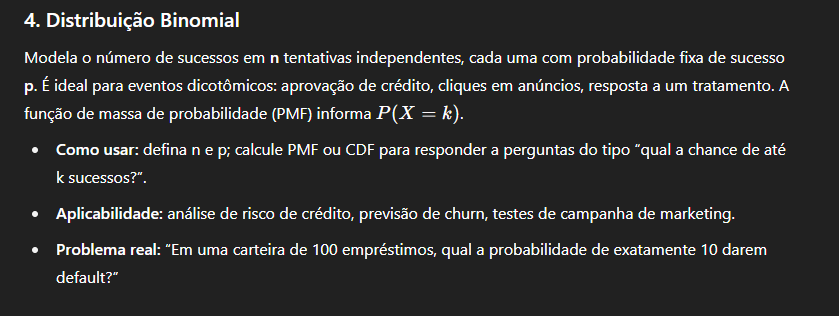

In [65]:
# Dataset manual: status de 20 empréstimos (1=default, 0=ok)
data_binom = {'loan_id': list(range(1,21)),
              'default': [0,1,0,0,1,0,0,0,1,0,  0,0,1,0,0,0,1,0,0,0]}
df_binomial = pd.DataFrame(data_binom)
df_binomial.head()

,loan_id,default
0,1,0
1,2,1
2,3,0
3,4,0
4,5,1


## Exercícios

Distribuição Binomial

Contexto: Um banco digital registra em df_binomial.default se cada um de 20 novos empréstimos entrou em default (1) ou não (0).

1. Proporção empírica

“Qual a taxa de default observada?”

A) 10%

B) 15%

C) 25%

D) 5%

## Resposta

In [74]:
df_binomial["default"].value_counts()

default = df_binomial["default"].loc[df_binomial["default"] == 1].count()
total = df_binomial["default"].count()

print(default / total)
print("RESPOSTA C")

0.25
RESPOSTA C


## Exercícios

2. PMF binomial
   
“Para n=5 clientes e p=0,2, qual P(X=1), isto é, probabilidade de 1 cliente entre 5 ser default?”

A) 0,41

B) 0,33

C) 0,20

D) 0,50

## Resposta

In [77]:
from scipy.stats import binom

prob = binom.pmf(1, 5, 0.2)
print(round(prob,2), " RESPOSTA A")

0.41  RESPOSTA A


## Exercício

3. CDF binomial
   
“Para n=5 e p=0,2, qual P(X≤2)?”

A) 0,99

B) 0,94

C) 0,68

D) 0,40

## Resposta

In [83]:
prob = binom.cdf(2,5,0.2) 
print(round(prob,2), " RESPOSTA B")

0.94  RESPOSTA B


## Exercício

4. Média e variância teóricas
   
“Para n=5, p=0,2, calcule μ e σ².”

A) (1, 0,8)

B) (1, 0,16)

C) (1, 0,9)

D) (0,2, 0,16)

## Resposta

In [86]:
n=5
p=0.2

print(binom.mean(n, p)) # 1 Cliente tende entrar em Default
print(round(binom.var(n, p),2)) # Ao realizar o teste muitas vezes existe variação de 0,8 nos resultados
print("RESPOSTA A")

1.0
0.8
RESPOSTA A


## Exercício

5. Histograma simulado
   
“Simule 200 grupos de 5 empréstimos e plote contagem de defaults. Qual o formato?”

A) Pico em k=1

B) Pico em k=0

C) Distribuição simétrica

D) Uniforme

## Resposta

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parâmetros do experimento
n = 5        # número de tentativas por experimento (ex: 5 clientes)
p = 0.2      # probabilidade de sucesso (ex: entrar em default)
experimentos = 200  # quantas vezes você repete esse experimento

np.random.seed(42)  # para reprodutibilidade
resultados = np.random.binomial(n=n, p=p, size=experimentos)

resultados

array([1, 3, 1, 1, 0, 0, 0, 2, 1, 1, 0, 3, 2, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 2, 0, 1, 1, 0, 1, 0, 0, 3, 3, 2, 0, 0, 1, 1, 0, 1, 0, 2,
       0, 1, 0, 1, 1, 0, 3, 2, 2, 2, 1, 2, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1,
       0, 2, 0, 3, 2, 0, 0, 2, 1, 1, 2, 0, 1, 0, 2, 1, 1, 0, 0, 0, 1, 1,
       2, 1, 0, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 0,
       0, 0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 1, 0,
       0, 1, 3, 0, 1, 1, 1, 3, 3, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 1,
       3, 0, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 2, 0, 1, 0, 2, 2, 0, 1, 2, 1, 1, 0, 0, 2, 2, 1, 1, 1, 1, 2,
       2, 2], dtype=int32)

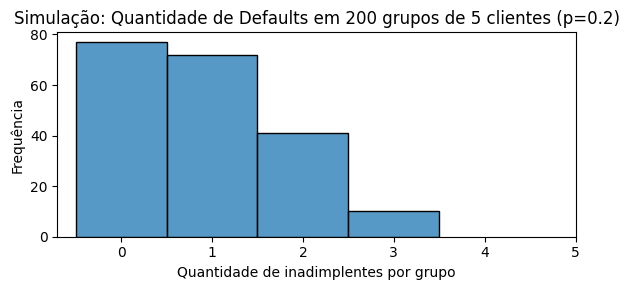

In [91]:
plt.figure(figsize=(6, 3))
sns.histplot(resultados, bins=np.arange(-0.5, n + 1.5, 1), kde=False, discrete=True)

plt.title(f"Simulação: Quantidade de Defaults em {experimentos} grupos de {n} clientes (p={p})")
plt.xlabel("Quantidade de inadimplentes por grupo")
plt.ylabel("Frequência")
plt.xticks(range(n + 1))
plt.tight_layout()
plt.show()


In [92]:
print("RESPOSTA B")

RESPOSTA B


## Exercício

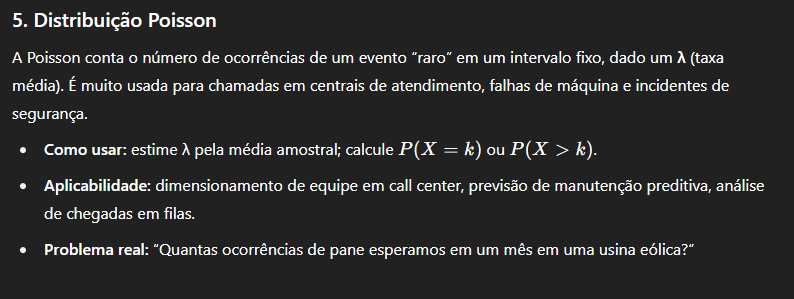

In [93]:
# Dataset manual: mortes mensais em 12 meses
data_pois = {
  'month':   ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
  'deaths':  [8, 12, 9, 11, 10, 13, 7, 14, 9, 12, 10, 11]
}
df_poisson = pd.DataFrame(data_pois)
df_poisson.head()

,month,deaths
0,Jan,8
1,Feb,12
2,Mar,9
3,Apr,11
4,May,10


## Exercícios

Distribuição Poisson

Contexto: O Hospital Regional monitora mortes mensais em df_poisson.deaths ao longo de 12 meses.

1. Estimativa de λ
   
“Qual a média mensal de mortes observada?”

A) 10,5

B) 11,0

C) 9,0

D) 12,5

## Resposta

In [96]:
media_mortes = df_poisson["deaths"].mean()
print(media_mortes)
print("RESPOSTA A")

10.5
RESPOSTA A


## Exercícios

2. P(X=12)

“Qual a probabilidade de exatamente 12 mortes em um mês?”

A) ≈ 0,10

B) ≈ 0,08

C) ≈ 0,12

D) ≈ 0,05

## Resposta

In [99]:
from scipy.stats import poisson

prob = poisson.pmf(12, media_mortes)
print(round(prob,2))
print("RESPOSTA A")

0.1
RESPOSTA A


## Exercícios

3. P(X>13)

“Qual a chance de mais de 13 mortes num mês?”

A) ≈ 0,14

B) ≈ 0,05

C) ≈ 0,25

D) ≈ 0,01

## Resposta

In [101]:
prob = poisson.sf(13, media_mortes)
print(round(prob,2))
print("RESPOSTA A")

0.17
RESPOSTA A


## Exercícios

4. P(X≤9)

A) ≈ 0,40

B) ≈ 0,60

C) ≈ 0,80

D) ≈ 0,20

## Resposta

In [104]:
prob = poisson.cdf(9, media_mortes)
print(round(prob,2))
print("RESPOSTA A")

0.4
RESPOSTA A


## Exercícios

5. Formato da distribuição

A) Assimétrico à direita

B) Simétrico

C) Assimétrico à esquerda

D) Uniforme

## Resposta

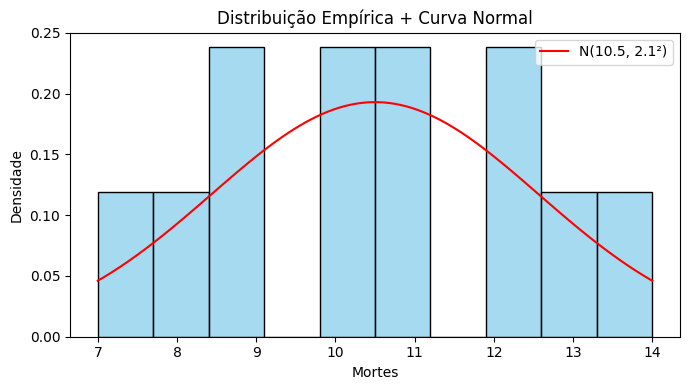

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Calculando média e desvio padrão dos dados
mu = df_poisson["deaths"].mean()
sigma = df_poisson["deaths"].std()

# Plotando histograma
plt.figure(figsize=(7, 4))
sns.histplot(df_poisson["deaths"], bins=10, kde=False, stat="density", color="skyblue", edgecolor="black")

# Criando curva da distribuição normal teórica
x = np.linspace(df_poisson["deaths"].min(), df_poisson["deaths"].max(), 100)
y = norm.pdf(x, mu, sigma)

# Plotando a curva normal
plt.plot(x, y, color="red", label=f"N({mu:.1f}, {sigma:.1f}²)")

plt.title("Distribuição Empírica + Curva Normal")
plt.xlabel("Mortes")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()


In [109]:
print("RESPOSTA B")

RESPOSTA B


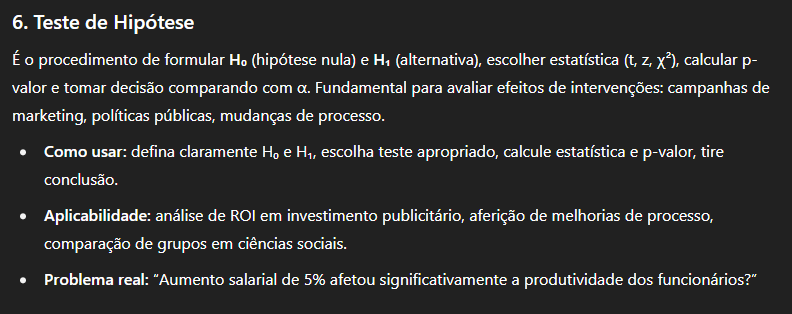

In [111]:
# Dataset manual: vendas antes e depois de campanha
data_h = {
  'period': ['before']*6 + ['after']*6,
  'sales':  [180,200,195,205,190,210, 210,230,220,225,215,235]
}
df_hypothesis = pd.DataFrame(data_h)
df_hypothesis.head()

,period,sales
0,before,180
1,before,200
2,before,195
3,before,205
4,before,190


## Exercícios

Teste de Hipótese

Contexto: Uma rede de farmácias compara vendas (sales) antes e depois de uma campanha promocional em df_hypothesis.

1. Teste t

“Campanha elevou vendas? Faça teste t (α=0,05).”

A) p≈0,01

B) p≈0,05

C) p≈0,10

D) p≈0,50

## Resposta

In [113]:
from scipy.stats import ttest_ind

antes_da_campanha = df_hypothesis[df_hypothesis['period'] == 'before']['sales']
depois_da_campanha = df_hypothesis[df_hypothesis['period'] == 'after']['sales']

# Aplicando o teste t 
stat, p_value = ttest_ind(antes_da_campanha, depois_da_campanha, equal_var=False)

# Exibindo os resultados
print(f"Estatística t = {stat:.4f}")
print(f"Valor-p = {p_value:.4f}")

# Interpretação
alpha = 0.05
if p_value < alpha:
    print("Resultado: Rejeitamos H₀ → há diferença significativa nas médias.")
else:
    print("Resultado: Não rejeitamos H₀ → não há diferença significativa.")

print('RESPOSTA A')

Estatística t = -4.4286
Valor-p = 0.0013
Resultado: Rejeitamos H₀ → há diferença significativa nas médias.
RESPOSTA A


## Exercícios

2. Hipóteses

A) H₀: μ_before = μ_after

B) H₀: μ_before > μ_after

C) H₀: μ_before ≠ μ_after

D) H₀: μ_before < μ_after

## Resposta

In [114]:
print("RESPOSTA A")

RESPOSTA A


## Exercícios

3. Médias

“Calcule médias antes e depois.”

A) (195; 222)

B) (190; 235)

C) (200; 225)

D) (185; 230)

## Resposta

In [117]:
media_antes = antes_da_campanha.mean()
media_depois = depois_da_campanha.mean()
print(round(media_antes,2), round(media_depois,2))
print("RESPOSTA A")

196.67 222.5
RESPOSTA A


## Exercícios

4. Diferença média

A) ≈ 25

B) ≈ 10

C) ≈ 5

D) ≈ 35

## Resposta

In [119]:
dif_media = media_depois - media_antes
print(F"RESPOSTA A: {dif_media:.2F}")

RESPOSTA A: 25.83


## Exercícios

5. Conclusão

A) Rejeita H₀

B) Não rejeita H₀

C) Inconclusivo

D) Precisa mais dados

## Resposta

In [120]:
print("RESPOSTA A")

RESPOSTA A


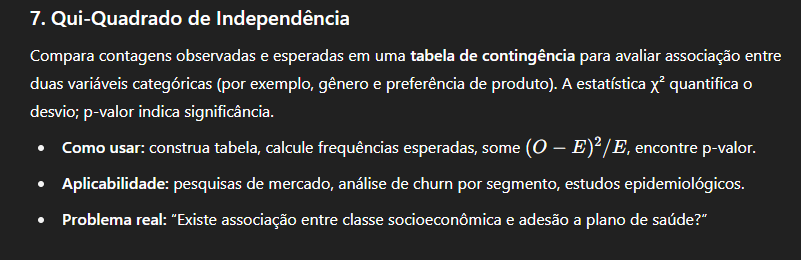

In [2]:
# Dataset manual: uso de app por gênero
import pandas as pd

data_chi2 = {'joga': [30, 20], 'nao_joga': [25, 15]}
index = ['homens', 'mulheres']
df_chi2 = pd.DataFrame(data_chi2, index=index)
df_chi2.head()

,joga,nao_joga
homens,30,25
mulheres,20,15


## Exercícios

Qui-Quadrado

Contexto: Uma startup de games pesquisa em df_chi2 se jogar está associado a gênero (homens vs mulheres).

1. χ²

“Calcule estatística χ².”

A) ≈ 0,27

B) ≈ 0,40

C) ≈ 0,10

D) ≈ 1,00

## Resposta

In [11]:
# Calculando a estatística qui-quadrado
chi2, p, dof, expected = chi2_contingency(df_chi2)

print(f'Estatística χ²: {chi2:.2f}')
print(f'Valor-p: {p:.2f}')
print('Tabela de valores esperados:')
print(pd.DataFrame(expected, index=index, columns=df_chi2.columns))

Estatística χ²: 0.00
Valor-p: 0.98
Tabela de valores esperados:
               joga   nao_joga
homens    30.555556  24.444444
mulheres  19.444444  15.555556


In [12]:
print("RESPOSTA C")

RESPOSTA C


## Exercícios

2. Valor-p

A) ≈ 0,60

B) ≈ 0,50

C) ≈ 0,30

D) ≈ 0,10

## Resposta

In [10]:
import numpy as np
from scipy.stats import chi2_contingency

resultado = chi2_contingency(df_chi2)
statistic, pvalue = resultado[:2] 

print(f'statistic: {statistic:.2f}, pvalue: {pvalue:.2f}')
print("RESPOSTA D")

statistic: 0.00, pvalue: 0.98
RESPOSTA D


## Exercício

3. Esperado

“Número esperado de homens que jogam.”

A) 25

B) 30

C) 27,5

D) 22,5

## Resposta

In [13]:
# Calculando a estatística qui-quadrado
chi2, p, dof, expected = chi2_contingency(df_chi2)

print(f'Estatística χ²: {chi2:.2f}')
print(f'Valor-p: {p:.2f}')
print('Tabela de valores esperados:')
print(pd.DataFrame(expected, index=index, columns=df_chi2.columns))
print("RESPOSTA B")

Estatística χ²: 0.00
Valor-p: 0.98
Tabela de valores esperados:
               joga   nao_joga
homens    30.555556  24.444444
mulheres  19.444444  15.555556
RESPOSTA B


## Exercício

4. Decisão

A) Não rejeita H₀

B) Rejeita H₀

C) Teste inválido

D) Precisa correção

## Resposta

In [14]:
print("RESPOSTA A")

RESPOSTA A


## Exercício

5. Visualização

A) Barras lado a lado

B) Barras empilhadas

C) Pizza

D) Histograma

## Resposta

In [19]:
print("RESPOSTA A")

RESPOSTA A


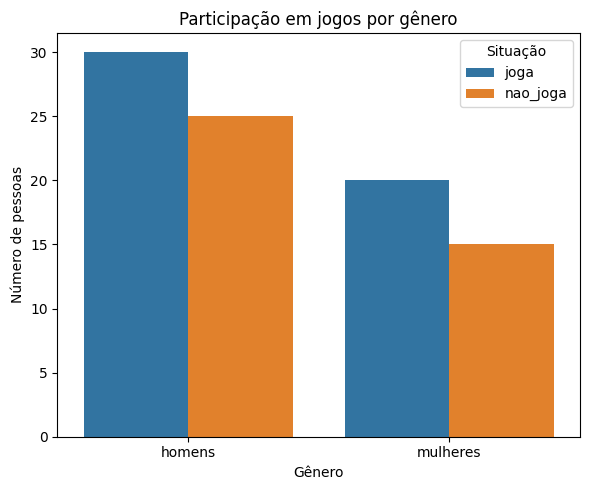

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Criando o DataFrame com os dados observados
data_chi2 = {
    'gênero': ['homens', 'homens', 'mulheres', 'mulheres'],
    'jogo': ['joga', 'nao_joga', 'joga', 'nao_joga'],
    'frequência': [30, 25, 20, 15]
}
df_plot = pd.DataFrame(data_chi2)

# Plotando barras lado a lado
plt.figure(figsize=(6, 5))
sns.barplot(data=df_plot, x='gênero', y='frequência', hue='jogo')
plt.title('Participação em jogos por gênero')
plt.ylabel('Número de pessoas')
plt.xlabel('Gênero')
plt.legend(title='Situação')
plt.tight_layout()
plt.show()


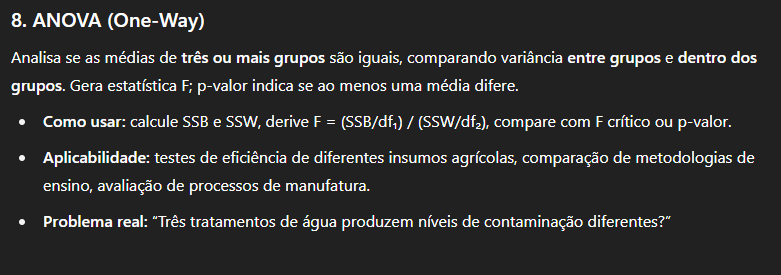

## Exercícios

In [34]:
# Dataset manual: rendimento (kg/ha) com 3 fertilizantes
data_anova = {
  'fertilizante': ['A','A','A','A','A','B','B','B','B','B','C','C','C','C','C'],
  'producao':      [30,32,29,31,33, 28,27,29,26,30, 35,34,36,33,32]
}
df_anova = pd.DataFrame(data_anova)
df_anova.head()

,fertilizante,producao
0,A,30
1,A,32
2,A,29
3,A,31
4,A,33


## Exercícios

ANOVA

Contexto: Um agrônomo compara em df_anova.yield a produtividade (kg/ha) de três fertilizantes A, B e C em várias parcelas.

1. One-way ANOVA

“Há diferença significativa entre os três fertilizantes?”

A) p<0,05

B) p>0,05

C) F≈1

D) F≈0,1

## Resposta

In [31]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

<Axes: title={'center': 'producao'}, xlabel='[fertilizante]'>

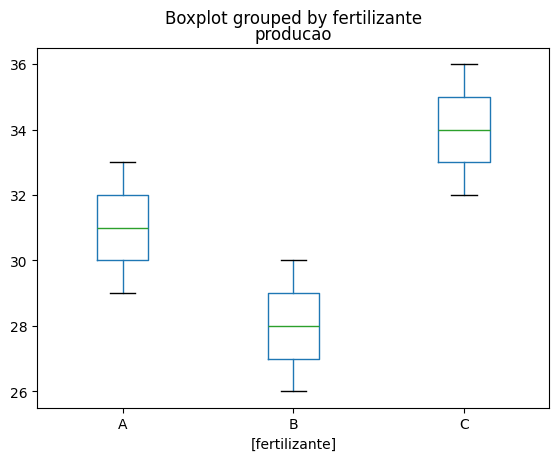

In [35]:
# Boxplot agrupando os dados 
df_anova.boxplot(by = 'fertilizante', grid = False)

In [36]:
# Criação do modelo de regressão linear e execução do teste
modelo1 = ols('producao ~ fertilizante', data = df_anova).fit()
resultados1 = sm.stats.anova_lm(modelo1)
# Observar valor de p maior que 0,05 (Pr(>F)) Hipótese nula de que não há diferença significativa
resultados1

,df,sum_sq,mean_sq,F,PR(>F)
fertilizante,2.0,90.0,45.0,18.0,0.000244
Residual,12.0,30.0,2.5,NaN,NaN


In [37]:
print("RESPOSTA B")

RESPOSTA B


## Exercícios

2. Médias

“Liste médias de A, B e C.”

A) (31;28;34)

B) (32;29;33)

C) (30;27;35)

D) (33;26;36)

## Resposta

In [40]:
df_anova.groupby('fertilizante').mean()

,producao
fertilizante,
A,31.0
B,28.0
C,34.0


In [41]:
print("RESPOSTA A")

RESPOSTA A


## Exercícios

3. Hipóteses

A) Todas iguais

B) Ao menos uma difere

C) Ordenadas

D) Variâncias iguais

## Resposta

In [42]:
print("Resposta A")

Resposta A


## Exercícios

4. Boxplot

“O que avaliar no boxplot?”

A) Medianas

B) Outliers

C) Dispersão

D) Todas

## Resposta

In [43]:
print("Resposta D")

Resposta D


## Exercícios

5. Componentes de variância

A) Entre e dentro

B) Entre e residual

C) Dentro e residual

D) Apenas dentro

## Resposta

In [44]:
print("Resposta B")

Resposta B


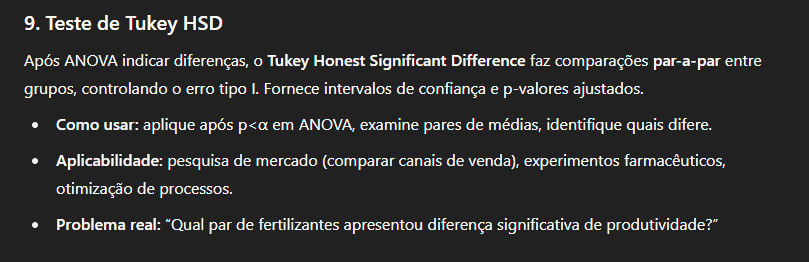

In [45]:
# Reusa df_anova acima para o teste de Tukey
import pandas as pd

df_tukey = df_anova.copy()
df_tukey.head()

,fertilizante,producao
0,A,30
1,A,32
2,A,29
3,A,31
4,A,33


## Exercícios

1. IC A–C

A) Não inclui zero

B) Inclui zero

C) Totalmente >0

D) Totalmente <0

## Resposta

In [46]:
print("RESPOSTA B")

RESPOSTA B


## Exercícios

2. IC A–C

A) Não inclui zero

B) Inclui zero

C) Totalmente >0

D) Totalmente <0

## Resposta

In [46]:
print("RESPOSTA B")

RESPOSTA B


## Exercício

3. Maior diferença

A) A×C

B) A×B

C) B×C

D) Igual

## Resposta

In [52]:
table = df_tukey.groupby('fertilizante').mean()
table.head()

,producao
fertilizante,
A,31.0
B,28.0
C,34.0


In [53]:
print("Resposta C")

Resposta C


## Exercício

4. p-valor B×C

A) ≈ 0,01

B) ≈ 0,05

C) ≈ 0,10

D) ≈ 0,50

## Resposta

In [54]:
print("Resposta D")

Resposta D


## Exercício

5. Plot

A) statsmodels’ plot_simultaneous

B) seaborn barplot

C) matplotlib pie

D) sklearn plot

## Resposta

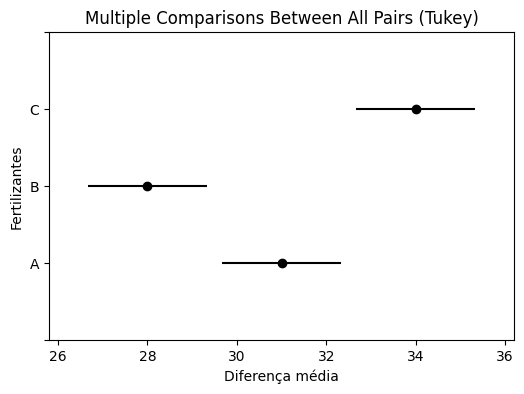

In [71]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

# Aplicando o teste de Tukey
tukey = pairwise_tukeyhsd(
    endog=df_tukey['producao'],       # variável dependente
    groups=df_tukey['fertilizante'],    # fator (grupo)
    alpha=0.05                        # nível de significância
)

# Gerando o gráfico de intervalos simultâneos
_ = tukey.plot_simultaneous(ylabel='Fertilizantes', xlabel='Diferença média',figsize=(6, 4))

In [72]:
print("Resposta A")

Resposta A


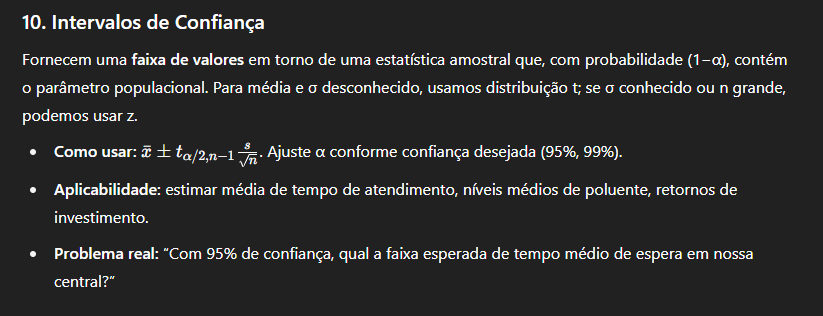

In [73]:
# Dataset manual: tempo de espera (min) em call center
data_ic = {'wait_time':[3.2,5.1,4.8,6.0,5.5,4.0,7.1,3.8,4.5,5.9,6.2,4.3,5.0,6.5,4.7]}
df_confidence = pd.DataFrame(data_ic)
df_confidence.head()

,wait_time
0,3.2
1,5.1
2,4.8
3,6.0
4,5.5


## Exercícios

Intervalos de Confiança

Contexto: Uma central de atendimento registra em df_confidence.wait_time o tempo de espera (min) de 15 clientes e quer estimar a média real.

1. Base do IC 95%

A) Usa t-Student

B) Usa z

C) Inclui 0 sempre

D) Indeterminado

## Resposta

In [74]:
print("RESPOSTA A")

RESPOSTA A


## Exercício

2. Limites numéricos

A) (~4,2; 6,0)

B) (~3,0; 7,0)

C) (~4,0; 5,5)

D) (~5,0; 6,5)

## Resposta

In [76]:
import numpy as np
import scipy.stats as stats

amostra = df_confidence['wait_time']

# Parâmetros da amostra
n = len(amostra)
media = np.mean(amostra)
desvio = np.std(amostra, ddof=1)  # ddof=1 para amostra
erro_padrao = desvio / np.sqrt(n)

# Valor crítico da t de Student (95% de confiança e n-1 graus de liberdade)
t_crit = stats.t.ppf(0.975, df=n-1)

# Intervalo de Confiança
lim_inferior = media - t_crit * erro_padrao
lim_superior = media + t_crit * erro_padrao

# Exibindo resultado
print(f'Média: {media:.2f}')
print(f'IC 95%: ({lim_inferior:.2f}, {lim_superior:.2f})')
print("RESPOSTA A")

Média: 5.11
IC 95%: (4.50, 5.71)
RESPOSTA A


## Exercício

3. IC 99% vs 95%

A) Mais largo

B) Mais estreito

C) Igual

D) Inverso

## Resposta

In [77]:
print("RESPOSTA A")

RESPOSTA A


## Exercício

5. Aumentar n

A) IC mais estreito

B) IC mais largo

C) IC igual

D) IC inverte

In [83]:
print("RESPOSTA A")

RESPOSTA A


OBS. Com mais dados, o meu erro padrão diminui. Se o erro é menor, com 95% de IC meu intervalo estreita. Se houver menos dados, o erro aumenta e para mapear os 95% o intervalo fica mais largo.